In [1]:
# set python path
import sys
sys.path.append('/home/jordan/repos/neuron_fitting')
from adexlif_ot_ficurve.adexlif_model import *

neuron_type = 'ipc'

# bank = default_parameter_bank(neuron_type)
bank = ParameterBank(
    parameters={
        "dt": IndependentScalarParameter(0.04),
        "T": IndependentScalarParameter(600),
        "delay": IndependentScalarParameter(200.0),
        "slope_time": IndependentScalarParameter(2.0),
        "Vthres": IndependentScalarParameter(0.0),
        "Tref": IndependentScalarParameter(2.0),
        "R": IndependentScalarParameter(0.061),
        "tRC": IndependentScalarParameter(23.192),
        "Vrest": IndependentScalarParameter(-58.03),
        "EL": IndependentScalarParameter(-58.05),
        "Ew": DerivedScalarParameter(lambda p: p["EL"]),
        "Vreset": IndependentScalarParameter(-59.36),
        "VTdelta": IndependentScalarParameter(1.484),
        "VT": DerivedScalarParameter(lambda p: p["Vreset"] + p["VTdelta"]),
        "Del": IndependentScalarParameter(0.224),
        "tau_w": IndependentScalarParameter(20.331),
        "a": IndependentScalarParameter(3.810),
        "b": IndependentScalarParameter(23.296),
    },
    constraints=[
        lambda p: p["a"] * p["R"] - p["tRC"] / p["tau_w"] < 0
    ],  # restrict to SN bifurcation
    array_mode=False,
)


print(bank.get_default_values())


ParameterSet(dt              0.040
T             600.000
delay         200.000
slope_time      2.000
Vthres          0.000
Tref            2.000
R               0.061
tRC            23.192
Vrest         -58.030
EL            -58.050
Ew            -58.050
Vreset        -59.360
VTdelta         1.484
VT            -57.876
Del             0.224
tau_w          20.331
a               3.810
b              23.296
dtype: float64)


# points in data: 13


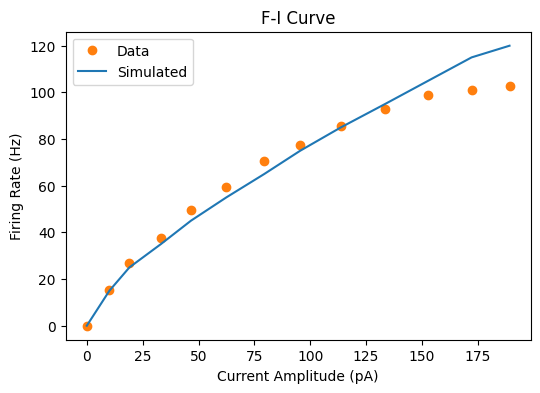

In [5]:
data = get_goddard_ficurve_data(n_thin=2)
current_amp_grid = data[neuron_type]["current"]
observed_freqs = data[neuron_type]["frequency"]
print("# points in data:", len(current_amp_grid))

experiment = AdExExperiment(param_dict=bank.get_default_values())
fig, ax = experiment.plot_f_i_curve(current_amplitudes=current_amp_grid, data=observed_freqs, figsize=(6, 4))
plt.show()

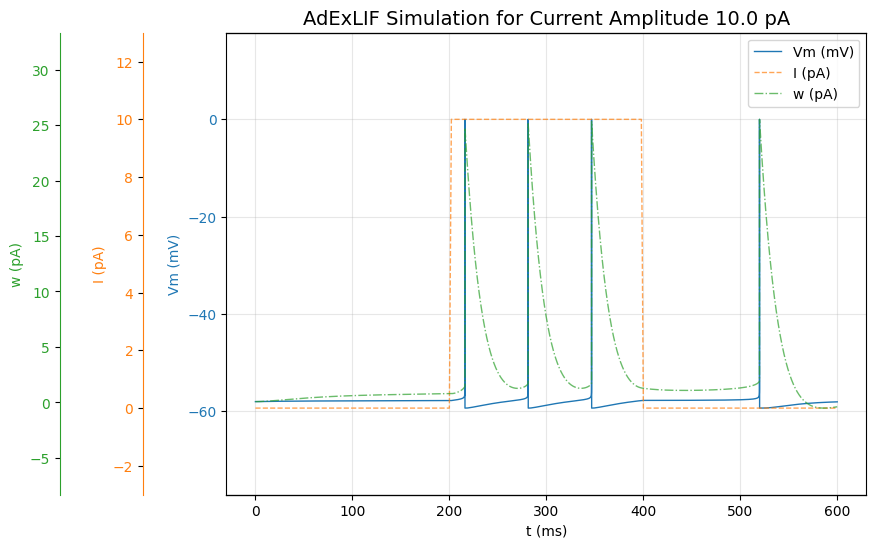

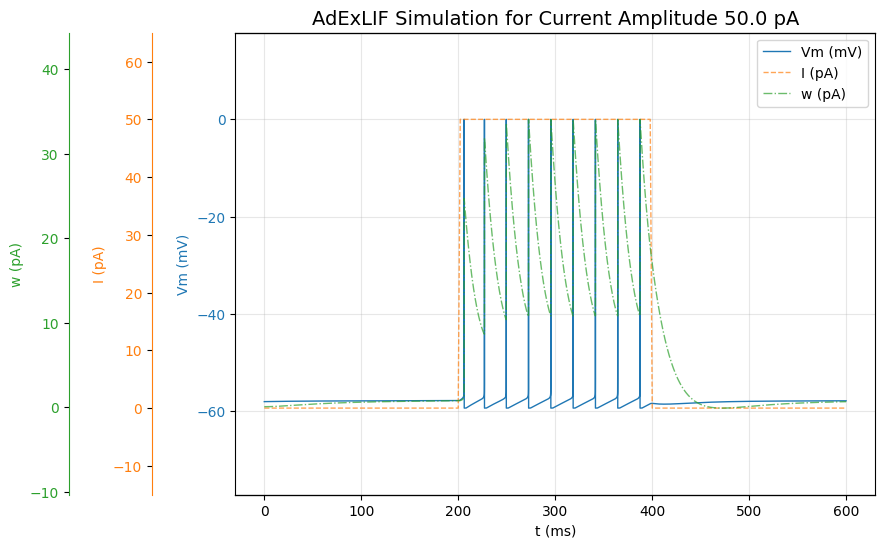

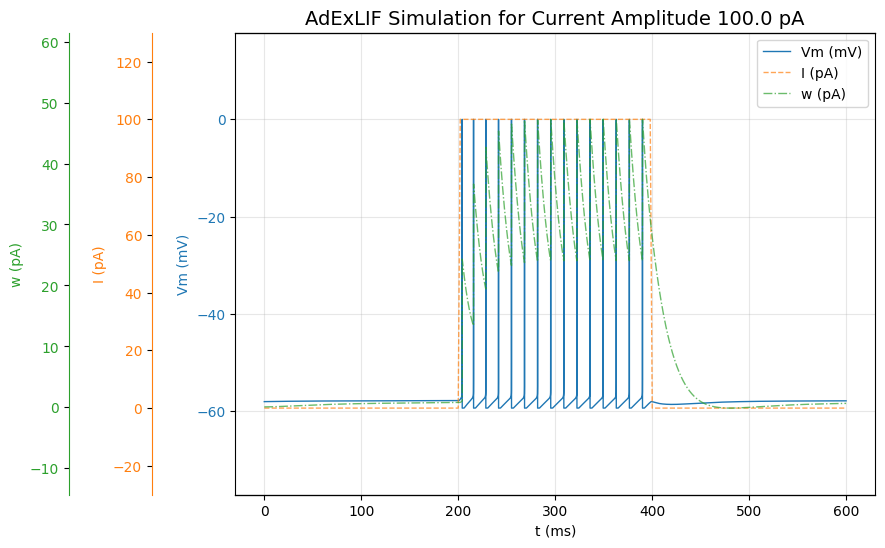

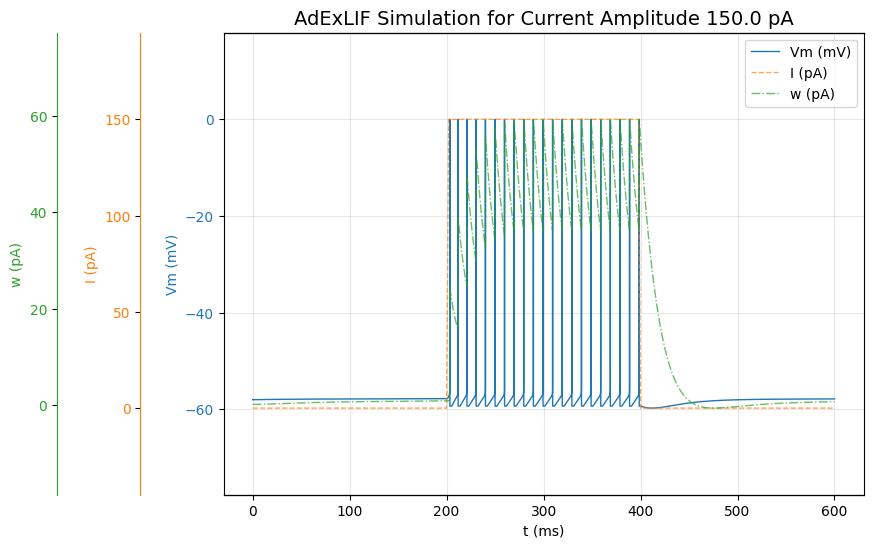

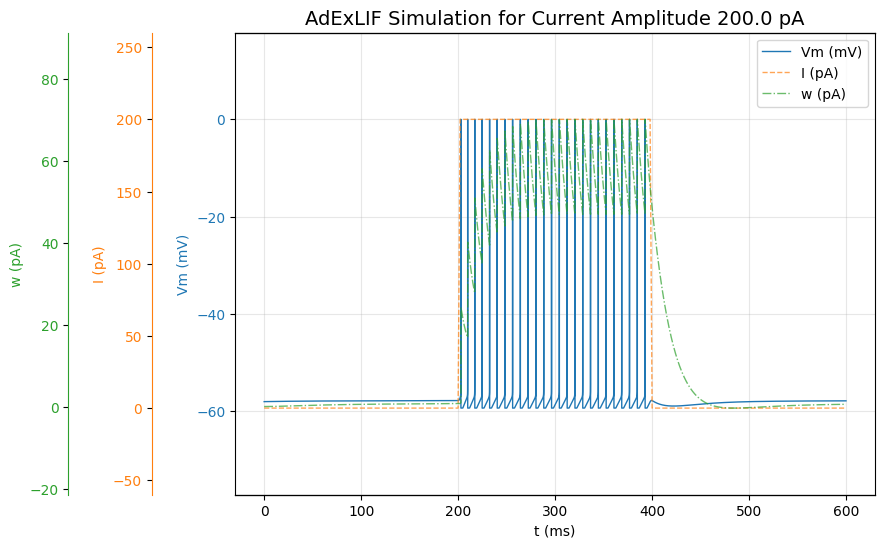

In [4]:
exp = AdExExperiment(param_dict=bank.get_default_values())
for amp in [10, 50, 100, 150, 200]:
    exp.plot_run(current_amplitude=amp, show_w=True)